In [1]:
2+2

4

In [2]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info: str

## Nodes


In [8]:
def start_play(state:State):
    print("Start_play nodes has been called")
    return {"graph_info": state['graph_info'] +  " I'm planning to start"}

def cricket(state:State):
    print("my cricket node has been called")
    return {"graph_info":state["graph_info"] + "cricket"}

def badmitton(state:State):
    print("my badmitton node has been called")
    return {"graph_info":state["graph_info"] + "badmitton"}

In [4]:
import random
from typing import Literal

def random_play(state:State)->Literal['cricket', 'badmitton']:
    graph_info=state['graph_info']

    if random.random()>0.5:
        return 'cricket'
    else:
        return 'badmitton'

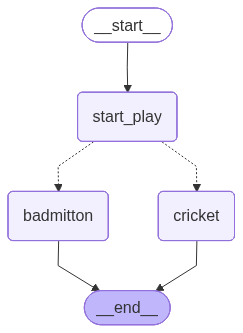

In [5]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## Build graph
graph=StateGraph(State)

## adding the nodes
graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("badmitton", badmitton)

## schedule the flow of the graph(adding edges)
graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("cricket",END)
graph.add_edge("badmitton",END)

## compile the graph
graph_builder = graph.compile()

## view the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

## Graph Invocation

In [9]:
graph_builder.invoke({"graph_info":"My name is prathmesh"})

Start_play nodes has been called
my badmitton node has been called


{'graph_info': "My name is prathmeshI'm planning to startbadmitton"}